In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# raiz="drive/MyDrive/proyecto_mineria/"
raiz=""

# Cargar datos y generar los conjuntos de entrenamiento y test

In [2]:
import pandas as pd
nombre_csv_logs="presentacion1_resultados.csv"
# file_path = 'data_set_limpio.pkl'
file_path = f'{raiz}datasets_pkl/data_set_limpio_sin_not_for_sale.pkl'

df = pd.read_pickle(file_path)

# Display the loaded DataFrame
print("shape: ",df.shape)
print(df.columns)
df.sample(n=5)


shape:  (186795, 70)
Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado'],
      dtype='object')


,Nat,Division,Club,Based,Preferred Foot,Right Foot,Left Foot,Position,Height,Weight,...,TRO,Sta,Str,Tck,Tea,Tec,Thr,Vis,Wor,transfer_value_estimado
19386,ARG,-,-,Argentina,Right Only,Very Strong,Weak,"DM, M (C)",179,73,...,3,13,11,11,12,8,2,9,11,0
68609,SUI,Swiss Lower Division,Seuzach,Switzerland (Lower Division),Right,Very Strong,Weak,ST (C),182,76,...,3,5,9,5,6,8,1,4,7,2000
107748,ISL,Icelandic Premier Division,Víkingur R.,Iceland (Premier Division),Right,Very Strong,Reasonable,GK,189,80,...,12,8,7,2,9,7,10,7,8,3750
8900,COL,Colombian Second Division,Real Cartagena,Colombia (Second Division),Right,Very Strong,Reasonable,AM (RL),179,68,...,3,10,4,5,7,13,3,8,12,495000
164920,ENG,JD Cymru North,Guilsfield,Wales (JD Cymru North),Right Only,Very Strong,Weak,D (R),186,77,...,2,8,6,8,6,5,1,2,6,0


# Generar conjuntos de entrenamiento y test

In [3]:
import pandas as pd
import json
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error

def log_results(model, method_name, X_train, y_train, X_test, y_test,
                filepath=f"{raiz}{nombre_csv_logs}.csv"):
    params_dict = model.get_params()
    for k, v in params_dict.items():
        try:
            json.dumps(v)
        except TypeError:
            params_dict[k] = str(v)
    params = json.dumps(params_dict)

    y_pred = model.predict(X_test)

    r2_train = model.score(X_train, y_train)
    r2_test  = model.score(X_test,  y_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    row = {
        "method":          method_name,
        "hyperparameters": json.dumps(params),
        "r2_train":        r2_train,
        "r2_test":         r2_test,
        "mae":             mae,
        "rmse":            rmse
    }

    residuals = y_test - y_pred
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(residuals, bins=50, kde=True, color="blue")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.title("Residuals Distribution")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
             color='red', linestyle='--')
    plt.title("Regression Fit: Actual vs Predicted")
    plt.xlabel("Actual Transfer Values")
    plt.ylabel("Predicted Transfer Values")

    plt.suptitle(method_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"  R² train : {r2_train:.4f}")
    print(f"  R² test  : {r2_test:.4f}")
    print(f"  MAE      : {mae:.2f}")
    print(f"  RMSE     : {rmse:.2f}")

    try:
        df_log = pd.read_csv(filepath)
        df_log = pd.concat([df_log, pd.DataFrame([row])], ignore_index=True)
    except FileNotFoundError:
        df_log = pd.DataFrame([row])

    df_log.to_csv(filepath, index=False)

# Generar conjuntos de entrenamiento y test

In [4]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [5]:
import clustering as cl

kmeans_model_club = cl.fit_kmeans(train_df, columna="Club")
kmeans_model_nat = cl.fit_kmeans(train_df, columna="Nat")
kmeans_model_division = cl.fit_kmeans(train_df, columna="Division")


train_df = cl.apply_kmeans(train_df, kmeans_model_club)
train_df = cl.apply_kmeans(train_df, kmeans_model_nat)
train_df = cl.apply_kmeans(train_df, kmeans_model_division)

test_df = cl.apply_kmeans(test_df, kmeans_model_club)
test_df = cl.apply_kmeans(test_df, kmeans_model_nat)
test_df = cl.apply_kmeans(test_df, kmeans_model_division)



# Considerar solo las más importantes
Si previamente ejecutamos el algoritmo y ya tenemos el archivo

In [6]:
import json
target="transfer_value_estimado"
with open("importantes.json", "r") as f:
    cols_to_keep = json.load(f)
    
cols_to_keep.append(target)
train_df=train_df[cols_to_keep]
test_df=train_df[cols_to_keep]

In [ ]:
drop_columns=["Club","Nat","Division",target]
X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df[target]

## One Hot para las features categóricas

In [8]:
# import numpy as np
# # categorical_cols=["Nat_cluster","Division_cluster","Club_cluster","Preferred Foot","Right Foot","Left Foot","Best Pos","Best Duty","Style","Best Role","Rc Injury"]
# categorical_cols=["Nat_cluster","Division_cluster","Best Duty","Style"]
# X_train = pd.get_dummies(X_train, columns=categorical_cols)
# X_test  = pd.get_dummies(X_test, columns=categorical_cols)

# X_train, X_test = X_train.align(X_test, join='left', axis=1,fill_value=0)

In [9]:
# X_train = X_train.select_dtypes(include=[np.number,np.bool_])
# X_test = X_test.select_dtypes(include=[np.number,np.bool_])

In [10]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train = pd.DataFrame(
#     scaler.fit_transform(X_train),
#     columns=X_train.columns,
#     index=X_train.index
# )

# X_test = pd.DataFrame(
#     scaler.transform(X_test),
#     columns=X_test.columns,
#     index=X_test.index
# )

# Entrenamiento

In [11]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Identify categorical columns
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Categorical columns: {cat_cols}")

# 2. Copy datasets
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# 3. Encode all categorical columns
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_encoded[cat_cols] = encoder.fit_transform(
    X_train[cat_cols]
)

X_test_encoded[cat_cols] = encoder.transform(
    X_test[cat_cols]
)

# 4. Train model
model = HistGradientBoostingRegressor()

# 

Categorical columns: ['Based', 'Team', 'Position', 'Right Foot', 'Preferred Foot', 'Best Pos']


# Entrenamiento y Evaluación

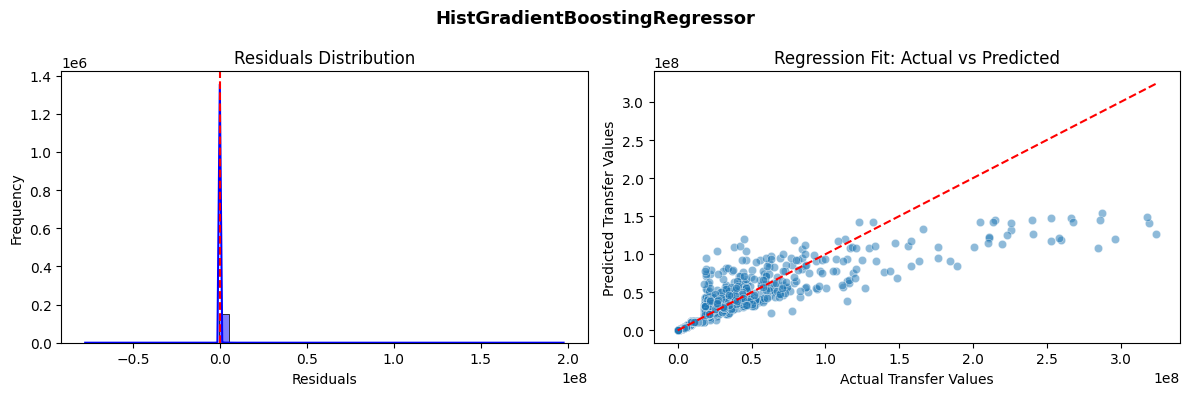

  R² train : 0.8064
  R² test  : 0.8064
  MAE      : 129702.34
  RMSE     : 2120722.31


In [12]:
model.fit(X_train_encoded, y_train)
# model.fit(X_train_encoded, y_train)

# # 5. Predict
preds = model.predict(X_test_encoded)
log_results(model,"HistGradientBoostingRegressor",X_train_encoded,y_train,X_test_encoded,y_test,filepath=nombre_csv_logs)

In [13]:
preds = model.predict(X_test_encoded)
print("saco ",model.score(X_test_encoded,y_test))
preds

saco  0.8064298358057913


array([ 50506.13930893,  50506.13930893,  50506.13930893, ...,
       132520.71456739,  50506.13930893,  50506.13930893], shape=(149436,))

# Feature importance

In [14]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model,          # trained HistGradientBoostingRegressor
    X_test_encoded,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "feature": X_test_encoded.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

print(importance_df)

                    feature  importance_mean  importance_std
40  transfer_value_estimado    600515.699942     1283.582639
0                      Wage     11865.770201      234.627170
1                       Age     10038.089312      731.578852
8                       Dec      6189.207051      668.899759
5                       Pac      6019.465946      595.018925
10                     Team      5079.667146      285.726270
2                     Based      4822.643967      634.698023
16                      Mar      2877.277261      623.185747
3                       Acc      2693.576755      111.762348
12                      Dri      2532.393382      252.248464
13                   AT Gls      2323.831557      209.491667
19                  AT Apps      1977.173090      152.884398
27                      Vis      1786.446137      254.076694
7                       Cmp      1585.841910      123.898562
18                   Height      1544.947922      163.120878
4                      C

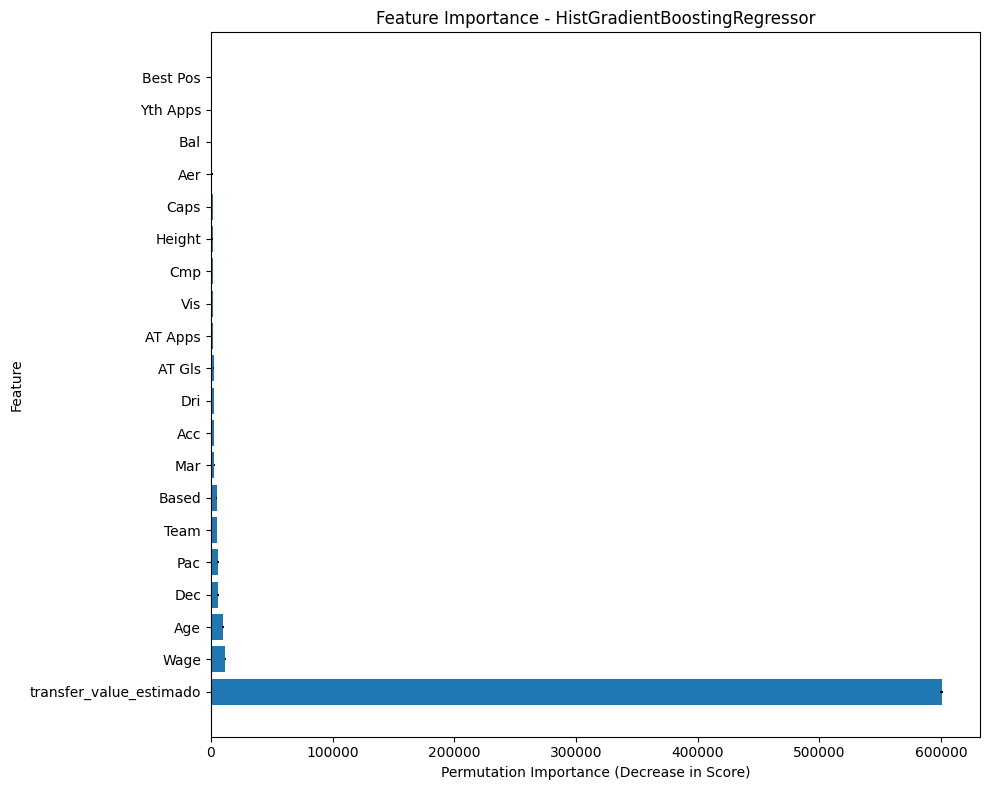

In [20]:
import matplotlib.pyplot as plt

# Optional: keep only top N features
top_n = 20
plot_df = importance_df.head(top_n)

# Create figure
plt.figure(figsize=(10, 8))

# Horizontal bar plot
plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"]
)

# Labels and title
plt.xlabel("Permutation Importance (Decrease in Score)")
plt.ylabel("Feature")
plt.title("Feature Importance - HistGradientBoostingRegressor")

# Highest importance at top
# plt.gca().invert_yaxis()

# Better spacing
plt.tight_layout()

# Show plot
plt.show()

In [16]:
import pandas as pd
visualizar_todo=True
if visualizar_todo:
    # Show all rows
    pd.set_option('display.max_rows', None)

    # Show all columns
    pd.set_option('display.max_columns', None)

    # Show full content of each cell (prevent text truncation)
    pd.set_option('display.max_colwidth', None)

print(importance_df)

                    feature  importance_mean  importance_std
40  transfer_value_estimado    600515.699942     1283.582639
0                      Wage     11865.770201      234.627170
1                       Age     10038.089312      731.578852
8                       Dec      6189.207051      668.899759
5                       Pac      6019.465946      595.018925
10                     Team      5079.667146      285.726270
2                     Based      4822.643967      634.698023
16                      Mar      2877.277261      623.185747
3                       Acc      2693.576755      111.762348
12                      Dri      2532.393382      252.248464
13                   AT Gls      2323.831557      209.491667
19                  AT Apps      1977.173090      152.884398
27                      Vis      1786.446137      254.076694
7                       Cmp      1585.841910      123.898562
18                   Height      1544.947922      163.120878
4                      C

In [17]:
genera_json=False
if genera_json:
    importantes=importance_df.loc[importance_df["importance_mean"] >= 0, "feature"].unique()
    importantes=importantes.tolist()
    import json

    with open("importantes.json", "w") as f:
        json.dump(importantes, f)


# Grid search

In [18]:
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'regressor__max_iter': [100, 200],
#     'regressor__learning_rate': [0.01, 0.1],
#     'regressor__max_leaf_nodes': [31, 63],
#     # You can even tune the preprocessor!
#     'prep__high_card__smooth': ['auto', 1.0] 
# }
# gbr_cv = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
# gbr_cv.fit(X_train, y_train)

## Evaluación

In [19]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# y_pred = gbr_cv.predict(X_test)
# mae=mean_absolute_error(y_test, y_pred)
# mse=mean_squared_error(y_test, y_pred)
# r2s=r2_score(y_test, y_pred)

# print("Best parameters ",gbr_cv.best_params_)
# print("mean_absolute_error: ",mae)
# print("mean_squared_error: ",mse)
# print("r2_score: ",r2s)